In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [3]:
model_data = pd.read_parquet("../data/processed/preprocessed_data.parquet")

In [4]:
print(f"Rows: {model_data.shape[0]:,}")
print(f"Columns: {model_data.shape[1]}")

Rows: 4,617,523
Columns: 84


In [5]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617523 entries, 0 to 4617522
Data columns (total 84 columns):
 #   Column                            Dtype         
---  ------                            -----         
 0   id                                object        
 1   item_id                           int64         
 2   d                                 object        
 3   sales                             int64         
 4   date                              datetime64[ns]
 5   wm_yr_wk                          int64         
 6   wday                              int64         
 7   month                             int64         
 8   year                              int64         
 9   snap_CA                           int64         
 10  snap_TX                           int64         
 11  snap_WI                           int64         
 12  sell_price                        float64       
 13  day                               int32         
 14  week              

In [6]:
missing = (
    model_data.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

print(missing)


key_cols = ["item_id", "date"]

duplicates = model_data.duplicated(subset=key_cols).sum()

print(f"Duplicate (item_id, store_id, date) rows: {duplicates}")

Series([], dtype: int64)
Duplicate (item_id, store_id, date) rows: 0


In [7]:
print(model_data.shape)
model_data.memory_usage(deep=True).sum() / 1024**3

(4617523, 84)


np.float64(3.2996850796043873)

In [8]:
with pd.option_context("display.max_columns", None):
    summary = model_data.describe(include="all").T

summary

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,4617523,3049,HOUSEHOLD_2_516_CA_1_validation,1885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,4617523.0,NaN,NaN,NaN,1521.910612,0.0,756.0,1518.0,2292.0,3048.0,886.733337
d,4617523,1885,d_1892,3049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,4617523.0,NaN,NaN,NaN,1.635163,0.0,0.0,0.0,2.0,648.0,4.453852
date,4617523,NaN,NaN,NaN,2014-01-17 23:01:51.571766784,2011-02-26 00:00:00,2012-11-24 00:00:00,2014-03-10 00:00:00,2015-04-11 00:00:00,2016-04-24 00:00:00,NaN
...,...,...,...,...,...,...,...,...,...,...,...
event_type_2_Cultural,4617523.0,NaN,NaN,NaN,0.001456,0.0,0.0,0.0,0.0,1.0,0.038127
event_type_2_No_Event,4617523.0,NaN,NaN,NaN,0.997943,0.0,1.0,1.0,1.0,1.0,0.045302
event_type_2_Religious,4617523.0,NaN,NaN,NaN,0.000601,0.0,0.0,0.0,0.0,1.0,0.024503
weekday_sin,4617523.0,NaN,NaN,NaN,-0.00116,-0.974928,-0.781831,0.0,0.781831,0.974928,0.707368


### Distribution of Sales


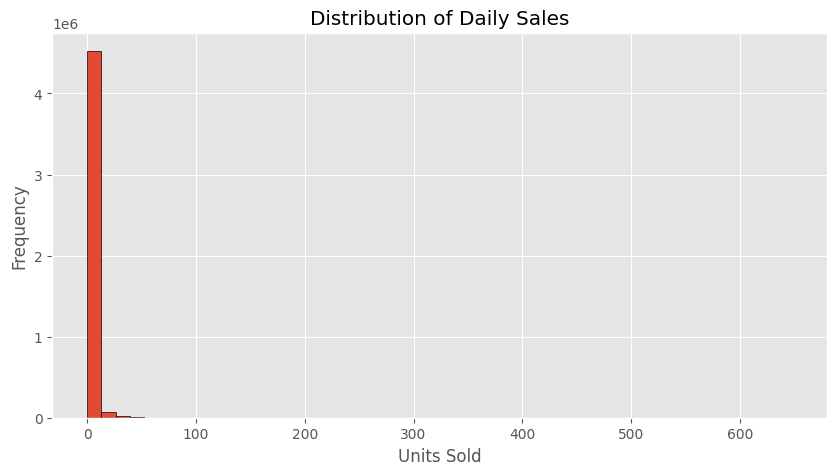

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(model_data["sales"], bins=50, edgecolor="black")

plt.title("Distribution of Daily Sales")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

In [10]:
#Percentage of Zero Sales
zero_sales = (model_data["sales"] == 0).sum()

total_sales = len(model_data)

print(f"Zero Sales Observations : {zero_sales:,}")
print(f"Percentage : {(zero_sales/total_sales)*100:.2f}%")

Zero Sales Observations : 2,554,445
Percentage : 55.32%


In [11]:
# What about the demand spread in sales
model_data["sales"].quantile(
    [0.25,0.50,0.75,0.90,0.95,0.99]
)

0.25     0.0
0.50     0.0
0.75     2.0
0.90     4.0
0.95     7.0
0.99    19.0
Name: sales, dtype: float64

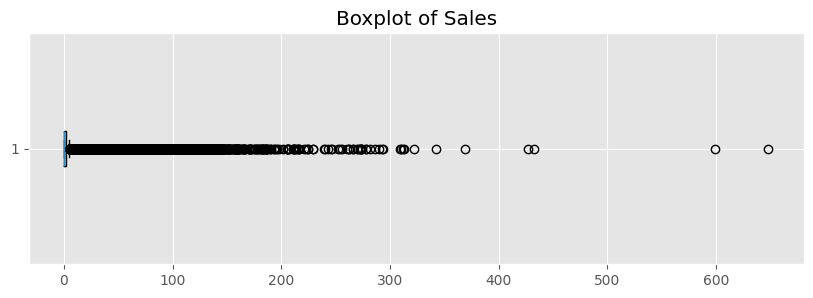

In [12]:
plt.figure(figsize=(10,3))

plt.boxplot(
    model_data["sales"],
    vert=False,
    showfliers=True
)

plt.title("Boxplot of Sales")

plt.show()

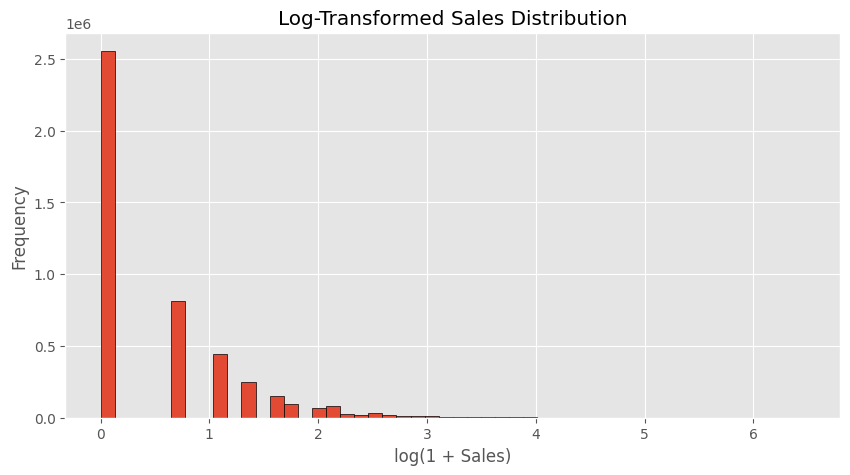

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(model_data["sales"]),
    bins=50,
    edgecolor="black"
)

plt.title("Log-Transformed Sales Distribution")
plt.xlabel("log(1 + Sales)")
plt.ylabel("Frequency")

plt.show()

### Business Insights

- More than half (**55.32%**) of the product-store-day observations recorded zero sales, indicating a high level of intermittent demand.
- The sales distribution is highly right-skewed, where most observations have low demand while a small number of observations experience very high sales.
- The presence of extreme sales values suggests demand spikes caused by factors such as holidays, promotions, or seasonal effects.
- High variability in demand highlights the importance of accurate forecasting and inventory optimization to avoid both stockouts and overstocking.

### Time Series Analysis

In [14]:
# Aggregate sales across all products for each date

daily_sales = (
    model_data
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,date,sales
0,2011-02-26,3389
1,2011-02-27,3214
2,2011-02-28,2045
3,2011-03-01,2333
4,2011-03-02,2347


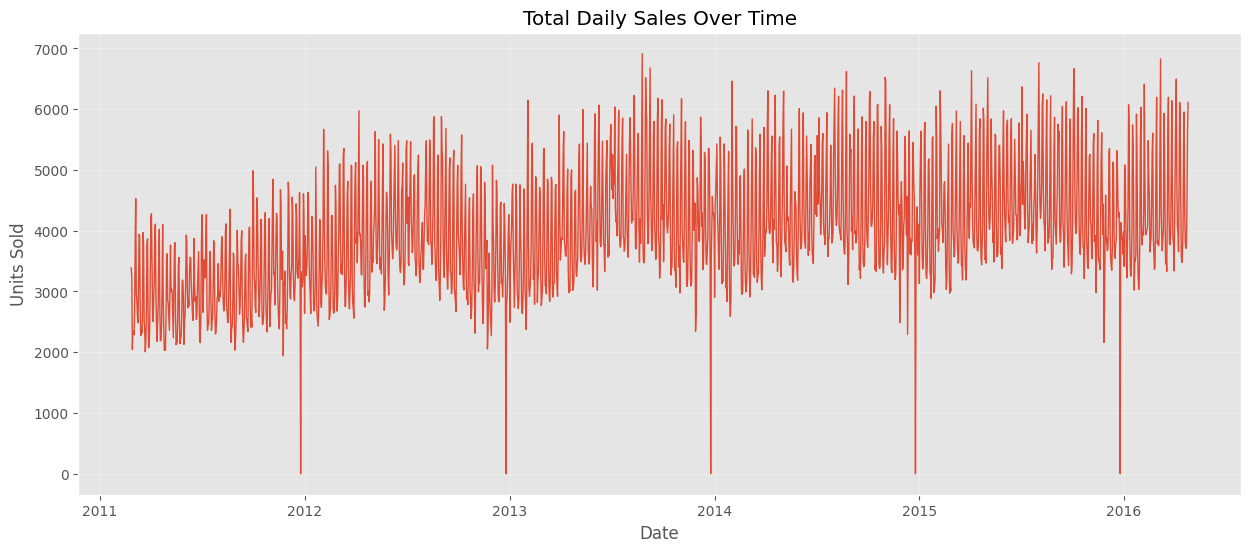

In [15]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    linewidth=1
)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.grid(alpha=0.3)

plt.show()

In [16]:
# Now checking monthly sales
monthly_sales = (
    model_data
    .groupby(["year", "month"])["sales"]
    .sum()
    .reset_index()
)

monthly_sales["date"] = (
    monthly_sales["year"].astype(str)
    + "-"
    + monthly_sales["month"].astype(str)
)

monthly_sales["date"] = pd.to_datetime(monthly_sales["date"])

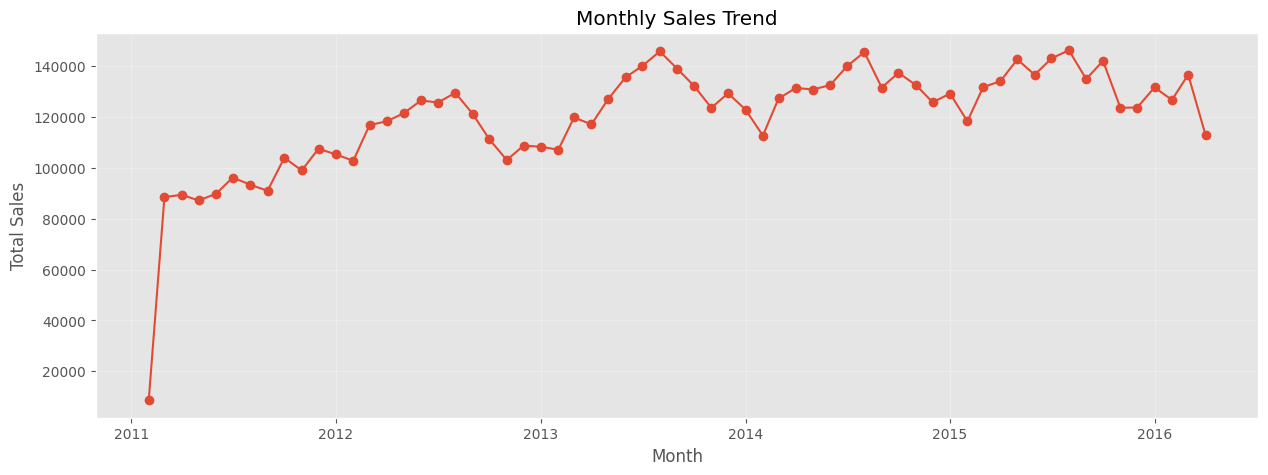

In [17]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)

plt.show()

In [18]:
model_data["weekday"] = model_data["date"].dt.day_name()

In [19]:
weekday_sales = (
    model_data
    .groupby("weekday")["sales"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

weekday_sales.head()



weekday
Monday       1.567336
Tuesday      1.386873
Wednesday    1.350444
Thursday     1.364894
Friday       1.634116
Name: sales, dtype: float64

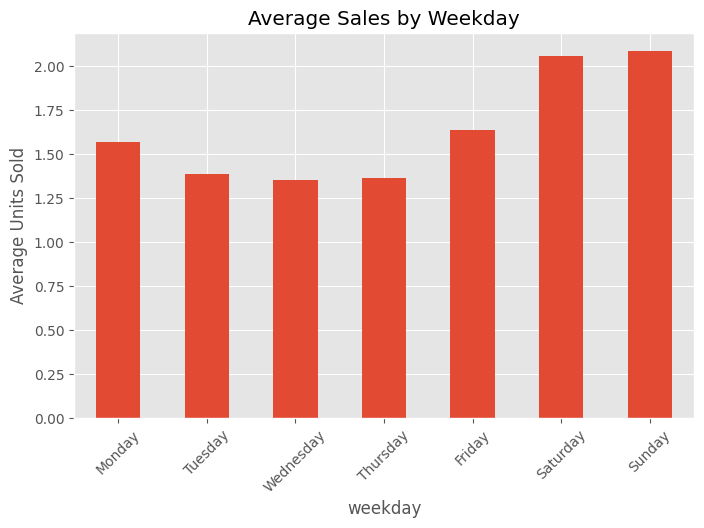

In [20]:
plt.figure(figsize=(8,5))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Weekday")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)

plt.show()

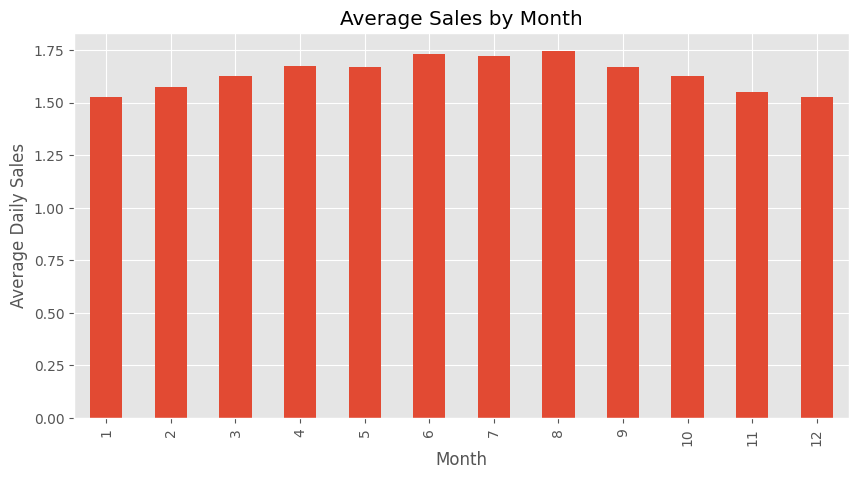

In [21]:
month_order = list(range(1,13))

month_sales = (
    model_data
    .groupby("month")["sales"]
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(10,5))

month_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.show()

Category
Intermittent    2210
Lumpy            527
Smooth           234
Erratic           78
Name: count, dtype: int64


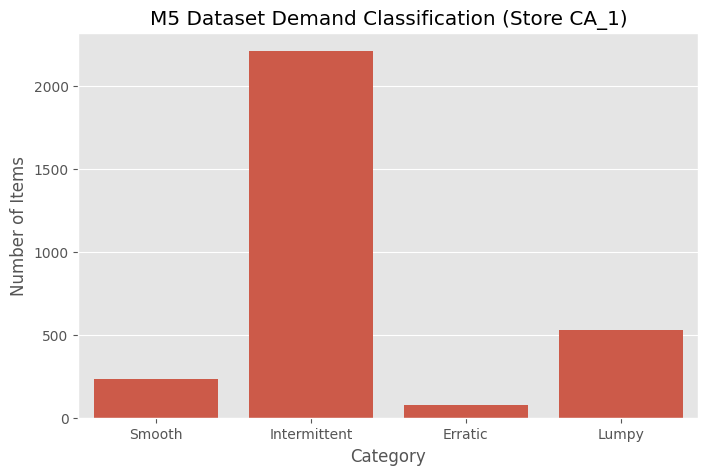

In [22]:
# Calculate ADI and CV^2 per item
def classify_demand(df):
    summary_stats = []
    
    for item, group in df.groupby('item_id'):
        # Filter for non-zero sales days
        nz_sales = group[group['sales'] > 0]['sales']
        total_days = len(group)
        nz_days = len(nz_sales)
        
        if nz_days <= 1:
            continue
            
        adi = total_days / nz_days
        cv2 = (nz_sales.std() / nz_sales.mean()) ** 2
        
        # Classification logic
        if adi < 1.32 and cv2 < 0.49:
            category = "Smooth"
        elif adi >= 1.32 and cv2 < 0.49:
            category = "Intermittent"
        elif adi < 1.32 and cv2 >= 0.49:
            category = "Erratic"
        else:
            category = "Lumpy"
            
        summary_stats.append({'item_id': item, 'ADI': adi, 'CV2': cv2, 'Category': category})
        
    return pd.DataFrame(summary_stats)

classification_df = classify_demand(model_data)
print(classification_df['Category'].value_counts())

# Plot the distribution
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.countplot(data=classification_df, x='Category', order=["Smooth", "Intermittent", "Erratic", "Lumpy"])
plt.title("M5 Dataset Demand Classification (Store CA_1)")
plt.ylabel("Number of Items")
plt.show()

In [23]:
# Calculate total revenue per product
model_data['revenue'] = model_data['sales'] * model_data['sell_price']
abc_analysis = model_data.groupby('item_id')['revenue'].sum().sort_values(ascending=False).reset_index()

# Calculate cumulative percentage
abc_analysis['cum_revenue'] = abc_analysis['revenue'].cumsum()
total_rev = abc_analysis['revenue'].sum()
abc_analysis['cum_percentage'] = (abc_analysis['cum_revenue'] / total_rev) * 100

# Classify
def assign_abc(pct):
    if pct <= 80: return 'A'
    elif pct <= 95: return 'B'
    else: return 'C'

abc_analysis['ABC_Class'] = abc_analysis['cum_percentage'].apply(assign_abc)
print(abc_analysis['ABC_Class'].value_counts())

ABC_Class
A    1208
B     923
C     918
Name: count, dtype: int64


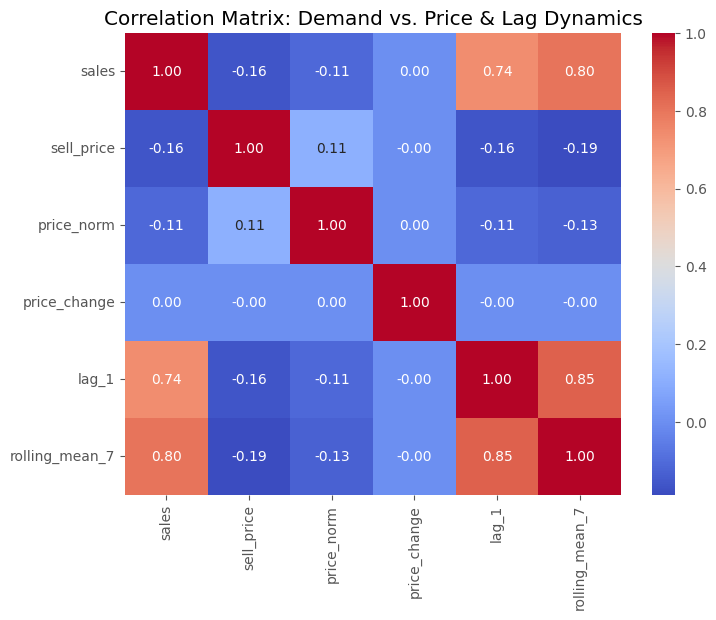

In [24]:
# Correlation between price_norm (relative price) and sales
correlation = model_data[['sales', 'sell_price', 'price_norm', 'price_change', 'lag_1', 'rolling_mean_7']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Demand vs. Price & Lag Dynamics")
plt.show()